In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

plt.style.use('fivethirtyeight')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('movies_metadata.csv')

In [3]:
df.shape

(45466, 24)

In [4]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [6]:
df.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


# Data Cleaning

In [7]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [8]:
df = df[['budget', 'runtime', 'popularity', 'vote_average', 
    'vote_count', 'release_date', 'genres', 'revenue']]

In [9]:
df = df.rename(columns={
    'budget': 'Budget',
    'runtime': 'Runtime',
    'popularity': 'Popularity',
    'vote_average': 'Vote_Average',
    'vote_count': 'Vote_Count',
    'release_date': 'Release_Date',
    'genres': 'Genres',
    'revenue': 'Revenue'
})

In [10]:
df.columns

Index(['Budget', 'Runtime', 'Popularity', 'Vote_Average', 'Vote_Count',
       'Release_Date', 'Genres', 'Revenue'],
      dtype='object')

In [11]:
df.head()

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000,81.0,21.946943,7.7,5415.0,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",373554033.0
1,65000000,104.0,17.015539,6.9,2413.0,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",262797249.0
2,0,101.0,11.7129,6.5,92.0,1995-12-22,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0.0
3,16000000,127.0,3.859495,6.1,34.0,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",81452156.0
4,0,106.0,8.387519,5.7,173.0,1995-02-10,"[{'id': 35, 'name': 'Comedy'}]",76578911.0


In [12]:
df.dtypes

Budget           object
Runtime         float64
Popularity       object
Vote_Average    float64
Vote_Count      float64
Release_Date     object
Genres           object
Revenue         float64
dtype: object

In [13]:
df.head()

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000,81.0,21.946943,7.7,5415.0,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",373554033.0
1,65000000,104.0,17.015539,6.9,2413.0,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",262797249.0
2,0,101.0,11.7129,6.5,92.0,1995-12-22,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0.0
3,16000000,127.0,3.859495,6.1,34.0,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",81452156.0
4,0,106.0,8.387519,5.7,173.0,1995-02-10,"[{'id': 35, 'name': 'Comedy'}]",76578911.0


In [14]:
df['Budget']  = pd.to_numeric(df['Budget'], errors='coerce')
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df["Popularity"] = pd.to_numeric(df["Popularity"], errors="coerce")

In [15]:
df.isna().sum()

Budget            3
Runtime         263
Popularity        6
Vote_Average      6
Vote_Count        6
Release_Date     87
Genres            0
Revenue           6
dtype: int64

In [16]:
df[df['Budget'].isna()]

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
19730,NaN,NaN,NaN,NaN,NaN,1,"[{'name': 'Carousel Productions', 'id': 11176}...",NaN
29503,NaN,NaN,NaN,NaN,NaN,12,"[{'name': 'Aniplex', 'id': 2883}, {'name': 'Go...",NaN
35587,NaN,NaN,NaN,NaN,NaN,22,"[{'name': 'Odyssey Media', 'id': 17161}, {'nam...",NaN


In [17]:
df = df.dropna(subset=['Budget'])

In [18]:
df.isna().sum()

Budget            0
Runtime         260
Popularity        3
Vote_Average      3
Vote_Count        3
Release_Date     87
Genres            0
Revenue           3
dtype: int64

In [19]:
df[df['Release_Date'].isna()]

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
711,0.0,95.0,0.005625,0.0,0.0,NaN,[],0.0
734,0.0,88.0,0.750000,0.0,0.0,NaN,[],0.0
3460,0.0,90.0,0.009057,0.0,0.0,NaN,"[{'id': 18, 'name': 'Drama'}]",10.0
3628,0.0,105.0,0.035352,2.0,1.0,NaN,[],0.0
5879,0.0,87.0,0.001181,0.0,0.0,NaN,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",0.0
...,...,...,...,...,...,...,...,...
45148,0.0,76.0,0.001586,6.0,2.0,NaN,[],0.0
45203,0.0,74.0,0.000220,4.0,1.0,NaN,"[{'id': 9648, 'name': 'Mystery'}, {'id': 878, ...",0.0
45338,0.0,0.0,0.000000,0.0,0.0,NaN,[],0.0
45410,0.0,NaN,0.008903,6.0,1.0,NaN,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",0.0


In [20]:
df = df.dropna(subset=['Budget', 'Revenue', 'Release_Date'])
df = df[(df['Budget'] > 0) & (df['Revenue'] > 0)]
df = df.reset_index(drop=True)

In [21]:
df.head()

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000.0,81.0,21.946943,7.7,5415.0,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",373554033.0
1,65000000.0,104.0,17.015539,6.9,2413.0,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",262797249.0
2,16000000.0,127.0,3.859495,6.1,34.0,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",81452156.0
3,60000000.0,170.0,17.924927,7.7,1886.0,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",187436818.0
4,35000000.0,106.0,5.231580,5.5,174.0,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",64350171.0


In [22]:
df

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000.0,81.0,21.946943,7.7,5415.0,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",373554033.0
1,65000000.0,104.0,17.015539,6.9,2413.0,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",262797249.0
2,16000000.0,127.0,3.859495,6.1,34.0,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",81452156.0
3,60000000.0,170.0,17.924927,7.7,1886.0,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",187436818.0
4,35000000.0,106.0,5.231580,5.5,174.0,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",64350171.0
...,...,...,...,...,...,...,...,...
5376,12000000.0,185.0,1.323587,6.9,25.0,2007-06-14,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",19000000.0
5377,750000.0,0.0,0.201582,6.0,4.0,2014-06-05,"[{'id': 80, 'name': 'Crime'}, {'id': 35, 'name...",3.0
5378,800000.0,100.0,0.903061,5.8,6.0,2006-11-23,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",1328612.0
5379,2000000.0,107.0,0.121844,4.0,3.0,2010-09-30,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",1268793.0


In [23]:
df['Genres'] = df['Genres'].apply(ast.literal_eval)

In [24]:
df['Primary_Genre'] = df['Genres'].apply(
    lambda x: x[0]['name'] if len(x) > 0 else 'Unknown'
)

In [25]:
df['Genres'] = df['Primary_Genre']
df = df.drop(columns=['Primary_Genre'])

In [26]:
df

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000.0,81.0,21.946943,7.7,5415.0,1995-10-30,Animation,373554033.0
1,65000000.0,104.0,17.015539,6.9,2413.0,1995-12-15,Adventure,262797249.0
2,16000000.0,127.0,3.859495,6.1,34.0,1995-12-22,Comedy,81452156.0
3,60000000.0,170.0,17.924927,7.7,1886.0,1995-12-15,Action,187436818.0
4,35000000.0,106.0,5.231580,5.5,174.0,1995-12-22,Action,64350171.0
...,...,...,...,...,...,...,...,...
5376,12000000.0,185.0,1.323587,6.9,25.0,2007-06-14,Action,19000000.0
5377,750000.0,0.0,0.201582,6.0,4.0,2014-06-05,Crime,3.0
5378,800000.0,100.0,0.903061,5.8,6.0,2006-11-23,Comedy,1328612.0
5379,2000000.0,107.0,0.121844,4.0,3.0,2010-09-30,Romance,1268793.0


In [27]:
df[df.isna().any(axis=1)]

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
5316,6000000.0,NaN,0.292296,1.0,1.0,2007-10-29,Drama,31000.0


In [28]:
df['Runtime'].median()

106.0

In [29]:
df['Runtime'] = np.where(df['Runtime'].isna(), 106.0, df['Runtime'])

In [30]:
df

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Release_Date,Genres,Revenue
0,30000000.0,81.0,21.946943,7.7,5415.0,1995-10-30,Animation,373554033.0
1,65000000.0,104.0,17.015539,6.9,2413.0,1995-12-15,Adventure,262797249.0
2,16000000.0,127.0,3.859495,6.1,34.0,1995-12-22,Comedy,81452156.0
3,60000000.0,170.0,17.924927,7.7,1886.0,1995-12-15,Action,187436818.0
4,35000000.0,106.0,5.231580,5.5,174.0,1995-12-22,Action,64350171.0
...,...,...,...,...,...,...,...,...
5376,12000000.0,185.0,1.323587,6.9,25.0,2007-06-14,Action,19000000.0
5377,750000.0,0.0,0.201582,6.0,4.0,2014-06-05,Crime,3.0
5378,800000.0,100.0,0.903061,5.8,6.0,2006-11-23,Comedy,1328612.0
5379,2000000.0,107.0,0.121844,4.0,3.0,2010-09-30,Romance,1268793.0


In [31]:
df.dtypes

Budget          float64
Runtime         float64
Popularity      float64
Vote_Average    float64
Vote_Count      float64
Release_Date     object
Genres           object
Revenue         float64
dtype: object

In [32]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [33]:
df['Release_Year'] = df['Release_Date'].dt.year

In [34]:
df['Release_Month'] = df['Release_Date'].dt.month

In [35]:
df['Release_Quarter'] = df['Release_Date'].dt.quarter

In [36]:
df = df.drop(columns=['Release_Date'])

In [37]:
df

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Genres,Revenue,Release_Year,Release_Month,Release_Quarter
0,30000000.0,81.0,21.946943,7.7,5415.0,Animation,373554033.0,1995,10,4
1,65000000.0,104.0,17.015539,6.9,2413.0,Adventure,262797249.0,1995,12,4
2,16000000.0,127.0,3.859495,6.1,34.0,Comedy,81452156.0,1995,12,4
3,60000000.0,170.0,17.924927,7.7,1886.0,Action,187436818.0,1995,12,4
4,35000000.0,106.0,5.231580,5.5,174.0,Action,64350171.0,1995,12,4
...,...,...,...,...,...,...,...,...,...,...
5376,12000000.0,185.0,1.323587,6.9,25.0,Action,19000000.0,2007,6,2
5377,750000.0,0.0,0.201582,6.0,4.0,Crime,3.0,2014,6,2
5378,800000.0,100.0,0.903061,5.8,6.0,Comedy,1328612.0,2006,11,4
5379,2000000.0,107.0,0.121844,4.0,3.0,Romance,1268793.0,2010,9,3


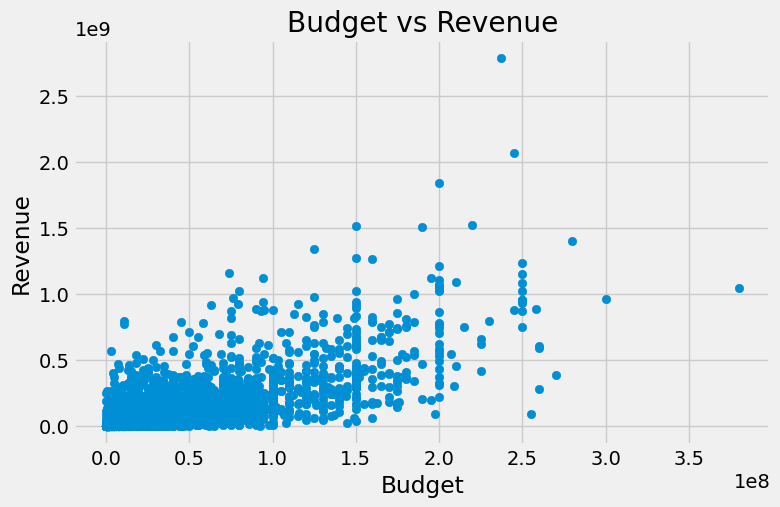

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df['Budget'], df['Revenue'])
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.title('Budget vs Revenue')
plt.show()

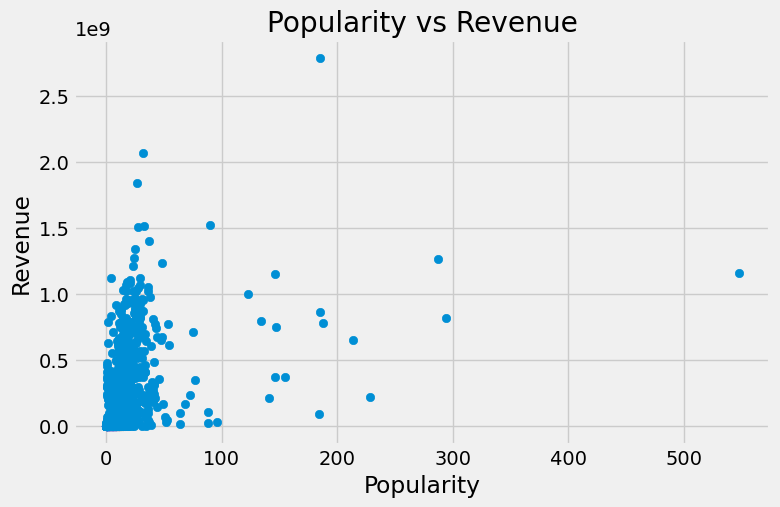

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(df['Popularity'], df['Revenue'])
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.title('Popularity vs Revenue')
plt.show()

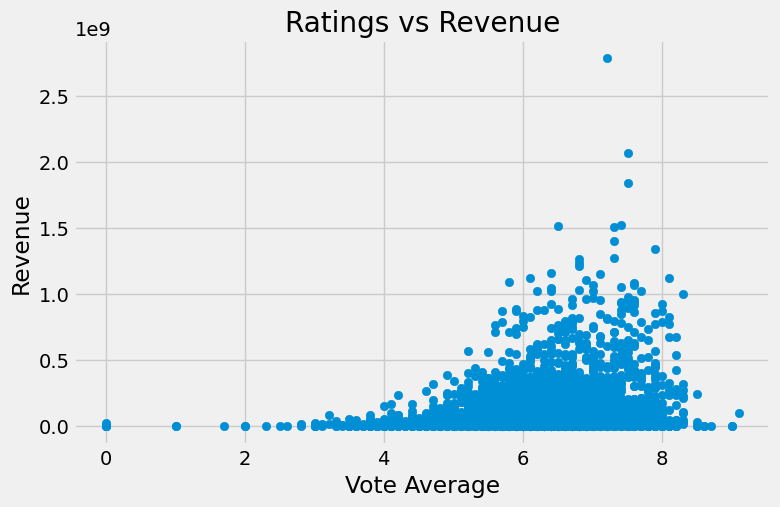

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['Vote_Average'], df['Revenue'])
plt.xlabel('Vote Average')
plt.ylabel('Revenue')
plt.title('Ratings vs Revenue')
plt.show()

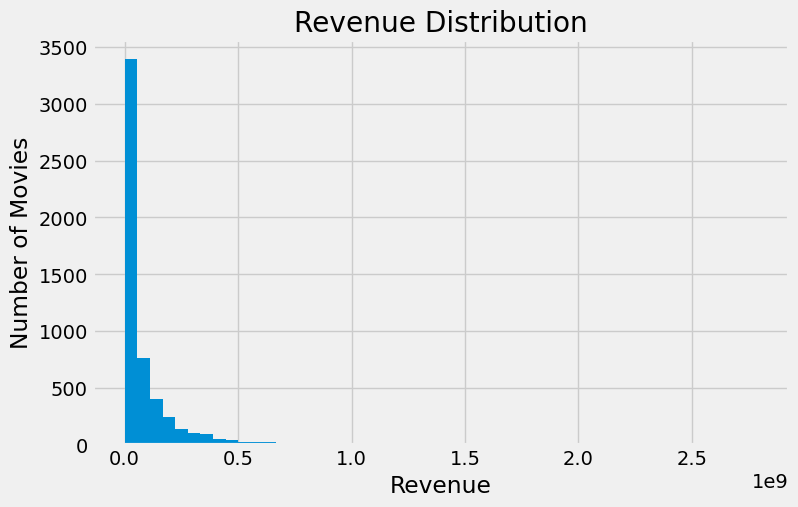

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df['Revenue'], bins=50)
plt.xlabel('Revenue')
plt.ylabel('Number of Movies')
plt.title('Revenue Distribution')
plt.show()

In [42]:
df['Revenue_Log'] = np.log1p(df['Revenue'])
df['Budget_Log'] = np.log1p(df['Budget'])

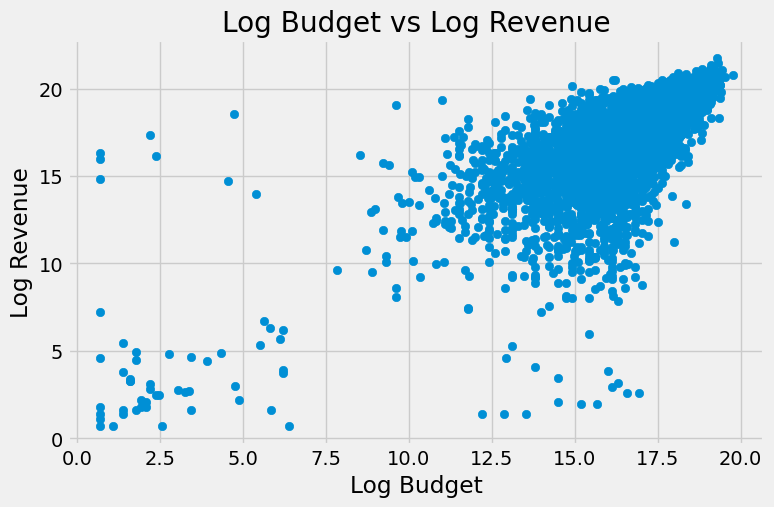

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df['Budget_Log'], df['Revenue_Log'])
plt.xlabel('Log Budget')
plt.ylabel('Log Revenue')
plt.title('Log Budget vs Log Revenue')
plt.show()

# Model

In [44]:
df

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Genres,Revenue,Release_Year,Release_Month,Release_Quarter,Revenue_Log,Budget_Log
0,30000000.0,81.0,21.946943,7.7,5415.0,Animation,373554033.0,1995,10,4,19.738573,17.216708
1,65000000.0,104.0,17.015539,6.9,2413.0,Adventure,262797249.0,1995,12,4,19.386893,17.989898
2,16000000.0,127.0,3.859495,6.1,34.0,Comedy,81452156.0,1995,12,4,18.215526,16.588099
3,60000000.0,170.0,17.924927,7.7,1886.0,Action,187436818.0,1995,12,4,19.048952,17.909855
4,35000000.0,106.0,5.231580,5.5,174.0,Action,64350171.0,1995,12,4,17.979850,17.370859
...,...,...,...,...,...,...,...,...,...,...,...,...
5376,12000000.0,185.0,1.323587,6.9,25.0,Action,19000000.0,2007,6,2,16.759950,16.300417
5377,750000.0,0.0,0.201582,6.0,4.0,Crime,3.0,2014,6,2,1.386294,13.527830
5378,800000.0,100.0,0.903061,5.8,6.0,Comedy,1328612.0,2006,11,4,14.099646,13.592368
5379,2000000.0,107.0,0.121844,4.0,3.0,Romance,1268793.0,2010,9,3,14.053577,14.508658


In [45]:
df.columns

Index(['Budget', 'Runtime', 'Popularity', 'Vote_Average', 'Vote_Count',
       'Genres', 'Revenue', 'Release_Year', 'Release_Month', 'Release_Quarter',
       'Revenue_Log', 'Budget_Log'],
      dtype='object')

In [46]:
df.dtypes

Budget             float64
Runtime            float64
Popularity         float64
Vote_Average       float64
Vote_Count         float64
Genres              object
Revenue            float64
Release_Year         int32
Release_Month        int32
Release_Quarter      int32
Revenue_Log        float64
Budget_Log         float64
dtype: object

In [47]:
cat_features = ['Genres']
num_features = ['Budget_Log', 'Runtime', 'Popularity', 'Vote_Average', 'Vote_Count', 
                'Release_Year', 'Release_Month', 'Release_Quarter']
target = "Revenue_Log"

In [48]:
X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features),
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [50]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Budget_Log',
                                                                          'Runtime',
                                                                          'Popularity',
                                                                          'Vote_Average',
                                                                          'Vote_Count',
                                                                          'Release_Year',
                                                                          'Release_Month',
                                                                          'Release_Quarter']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImpu...='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Genres'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [200, 400]},
             scoring='r2', verbose=1)

In [51]:
best_model = grid_search.best_estimator_

In [52]:
train_pred = best_model.predict(X_train)
test_pred  = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)

In [53]:
print("=" * 60)
print("Movie Success Predictor (Revenue_Log)")
print("=" * 60)
print("Best Hyperparameters:", grid_search.best_params_)
print("-" * 60)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print()
print(f"Train R²:   {train_r2:.4f}")
print(f"Test  R²:   {test_r2:.4f}")
print("=" * 60)

Movie Success Predictor (Revenue_Log)
Best Hyperparameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
------------------------------------------------------------
Train RMSE: 0.8515
Test  RMSE: 1.5372

Train R²:   0.8945
Test  R²:   0.6491


In [54]:
new_movie = pd.DataFrame([{
    "Budget_Log": np.log1p(50000000), 
    "Runtime": 120,
    "Popularity": 25.0,
    "Vote_Average": 7.2,
    "Vote_Count": 3000,
    "Release_Year": 2020,
    "Release_Month": 7,
    "Release_Quarter": 3,
    "Genres": "Action"
}])

In [55]:
pred_revenue_log = best_model.predict(new_movie)[0]

In [56]:
pred_revenue = np.expm1(pred_revenue_log)

In [57]:
print("\n--- New Movie Prediction ---")
print(f"Predicted Revenue_Log: {pred_revenue_log:.4f}")
print(f"Estimated Revenue:     ${pred_revenue:,.0f}")


--- New Movie Prediction ---
Predicted Revenue_Log: 19.1191
Estimated Revenue:     $201,061,279


In [58]:
df.head()

,Budget,Runtime,Popularity,Vote_Average,Vote_Count,Genres,Revenue,Release_Year,Release_Month,Release_Quarter,Revenue_Log,Budget_Log
0,30000000.0,81.0,21.946943,7.7,5415.0,Animation,373554033.0,1995,10,4,19.738573,17.216708
1,65000000.0,104.0,17.015539,6.9,2413.0,Adventure,262797249.0,1995,12,4,19.386893,17.989898
2,16000000.0,127.0,3.859495,6.1,34.0,Comedy,81452156.0,1995,12,4,18.215526,16.588099
3,60000000.0,170.0,17.924927,7.7,1886.0,Action,187436818.0,1995,12,4,19.048952,17.909855
4,35000000.0,106.0,5.231580,5.5,174.0,Action,64350171.0,1995,12,4,17.979850,17.370859


In [60]:
import joblib

joblib.dump(best_model, "best_model.joblib")

['best_model.joblib']